In [34]:
!pip install -q statsmodels seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [35]:
FILE_PATH = 'cafe_seguro_master.csv'  # <── ajusta si el nombre es diferente

df = pd.read_csv(FILE_PATH, parse_dates=['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Período: {df["fecha"].min().date()} → {df["fecha"].max().date()}')
print(f'\nColumnas:\n{df.dtypes}')
df.head(10)

Shape: (288, 10)
Período: 2002-01-01 → 2025-12-01

Columnas:
fecha                        datetime64[ns]
year                                  int64
month                                 int64
prod_caldas_miles_sacos             float64
prod_nacional_miles_sacos           float64
precip_mm                           float64
ndvi_mean                           float64
ndvi_median                         float64
ndvi_p90                            float64
precio_interno_cop                  float64
dtype: object


,fecha,year,month,prod_caldas_miles_sacos,prod_nacional_miles_sacos,precip_mm,ndvi_mean,ndvi_median,ndvi_p90,precio_interno_cop
0,2002-01-01,2002,1,84.600091,824.0,118.092200,0.803733,0.822325,0.888642,276480.0
1,2002-02-01,2002,2,82.957371,808.0,135.231310,0.745381,0.779234,0.865231,270960.0
2,2002-03-01,2002,3,79.877271,778.0,234.066220,0.684195,0.732444,0.845712,296859.0
3,2002-04-01,2002,4,96.715153,942.0,366.398070,0.748634,0.794900,0.865153,307892.0
4,2002-05-01,2002,5,114.169055,1112.0,275.821470,0.766095,0.802754,0.869108,284464.0
5,2002-06-01,2002,6,108.008854,1052.0,168.282410,0.792068,0.814389,0.869081,277875.0
6,2002-07-01,2002,7,89.117572,868.0,151.654040,0.782374,0.798860,0.865176,264823.0
7,2002-08-01,2002,8,77.105180,751.0,110.342415,0.745217,0.775433,0.853447,260185.0
8,2002-09-01,2002,9,79.877271,778.0,232.683820,0.759474,0.783222,0.861228,302300.0
9,2002-10-01,2002,10,109.240895,1064.0,313.142880,0.617553,0.730591,0.855365,311722.0


In [36]:
# Conteo de nulos
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'pct': pct_nulos})
print('Valores nulos por columna:')
print(resumen_nulos[resumen_nulos['nulos'] > 0])

df_ndvi = df[df['ndvi_mean'].notna()]
print(f'\nNDVI disponible: {df_ndvi["fecha"].min().date()} → {df_ndvi["fecha"].max().date()}')
print(f'Registros con NDVI: {len(df_ndvi)} de {len(df)} ({len(df_ndvi)/len(df)*100:.1f}%)')

Valores nulos por columna:
Empty DataFrame
Columns: [nulos, pct]
Index: []

NDVI disponible: 2002-01-01 → 2025-12-01
Registros con NDVI: 288 de 288 (100.0%)


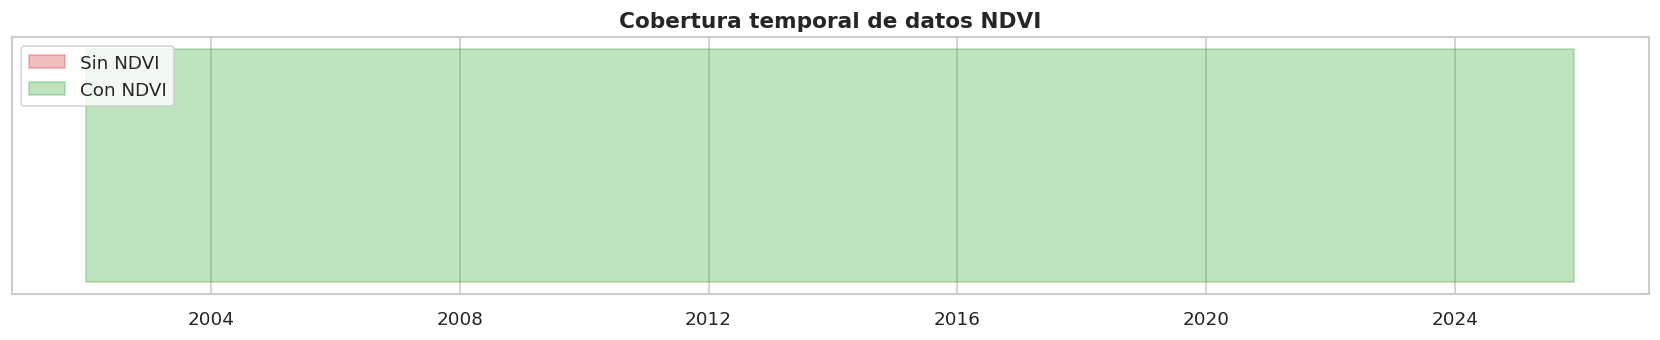

In [37]:
# Mapa visual de cobertura NDVI
fig, ax = plt.subplots(figsize=(14, 3))

ax.fill_between(df['fecha'], 0, 1,
                where=df['ndvi_mean'].isna(),
                color='#d62728', alpha=0.3, label='Sin NDVI')
ax.fill_between(df['fecha'], 0, 1,
                where=df['ndvi_mean'].notna(),
                color='#2ca02c', alpha=0.3, label='Con NDVI')

ax.set_title('Cobertura temporal de datos NDVI', fontsize=13, fontweight='bold')
ax.set_yticks([])
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('ndvi_cobertura.png', bbox_inches='tight')
plt.show()

In [38]:
# Descriptivas extendidas con CV, skewness y kurtosis
vars_numericas = ['prod_caldas_miles_sacos', 'prod_nacional_miles_sacos',
                  'precip_mm', 'ndvi_mean', 'precio_interno_cop']

desc = df[vars_numericas].describe().T
desc['cv']   = (desc['std'] / desc['mean'] * 100).round(1)
desc['skew'] = df[vars_numericas].skew().round(3)
desc['kurt'] = df[vars_numericas].kurt().round(3)
print('Estadísticas descriptivas extendidas:')
desc.round(3)

Estadísticas descriptivas extendidas:


,count,mean,std,min,25%,50%,75%,max,cv,skew,kurt
prod_caldas_miles_sacos,288.0,82.196,21.918,32.600,66.763,80.051,96.322,152.105,26.7,0.400,0.048
prod_nacional_miles_sacos,288.0,987.890,258.865,345.000,806.147,995.000,1152.615,1798.231,26.2,0.196,0.118
precip_mm,288.0,239.810,92.300,31.473,164.560,242.074,302.330,637.939,38.5,0.304,0.397
ndvi_mean,288.0,0.743,0.056,0.446,0.720,0.756,0.782,0.827,7.5,-1.884,6.031
precio_interno_cop,288.0,918242.907,648384.953,260185.000,476387.723,728750.000,1011100.726,3118571.429,70.6,1.661,2.134


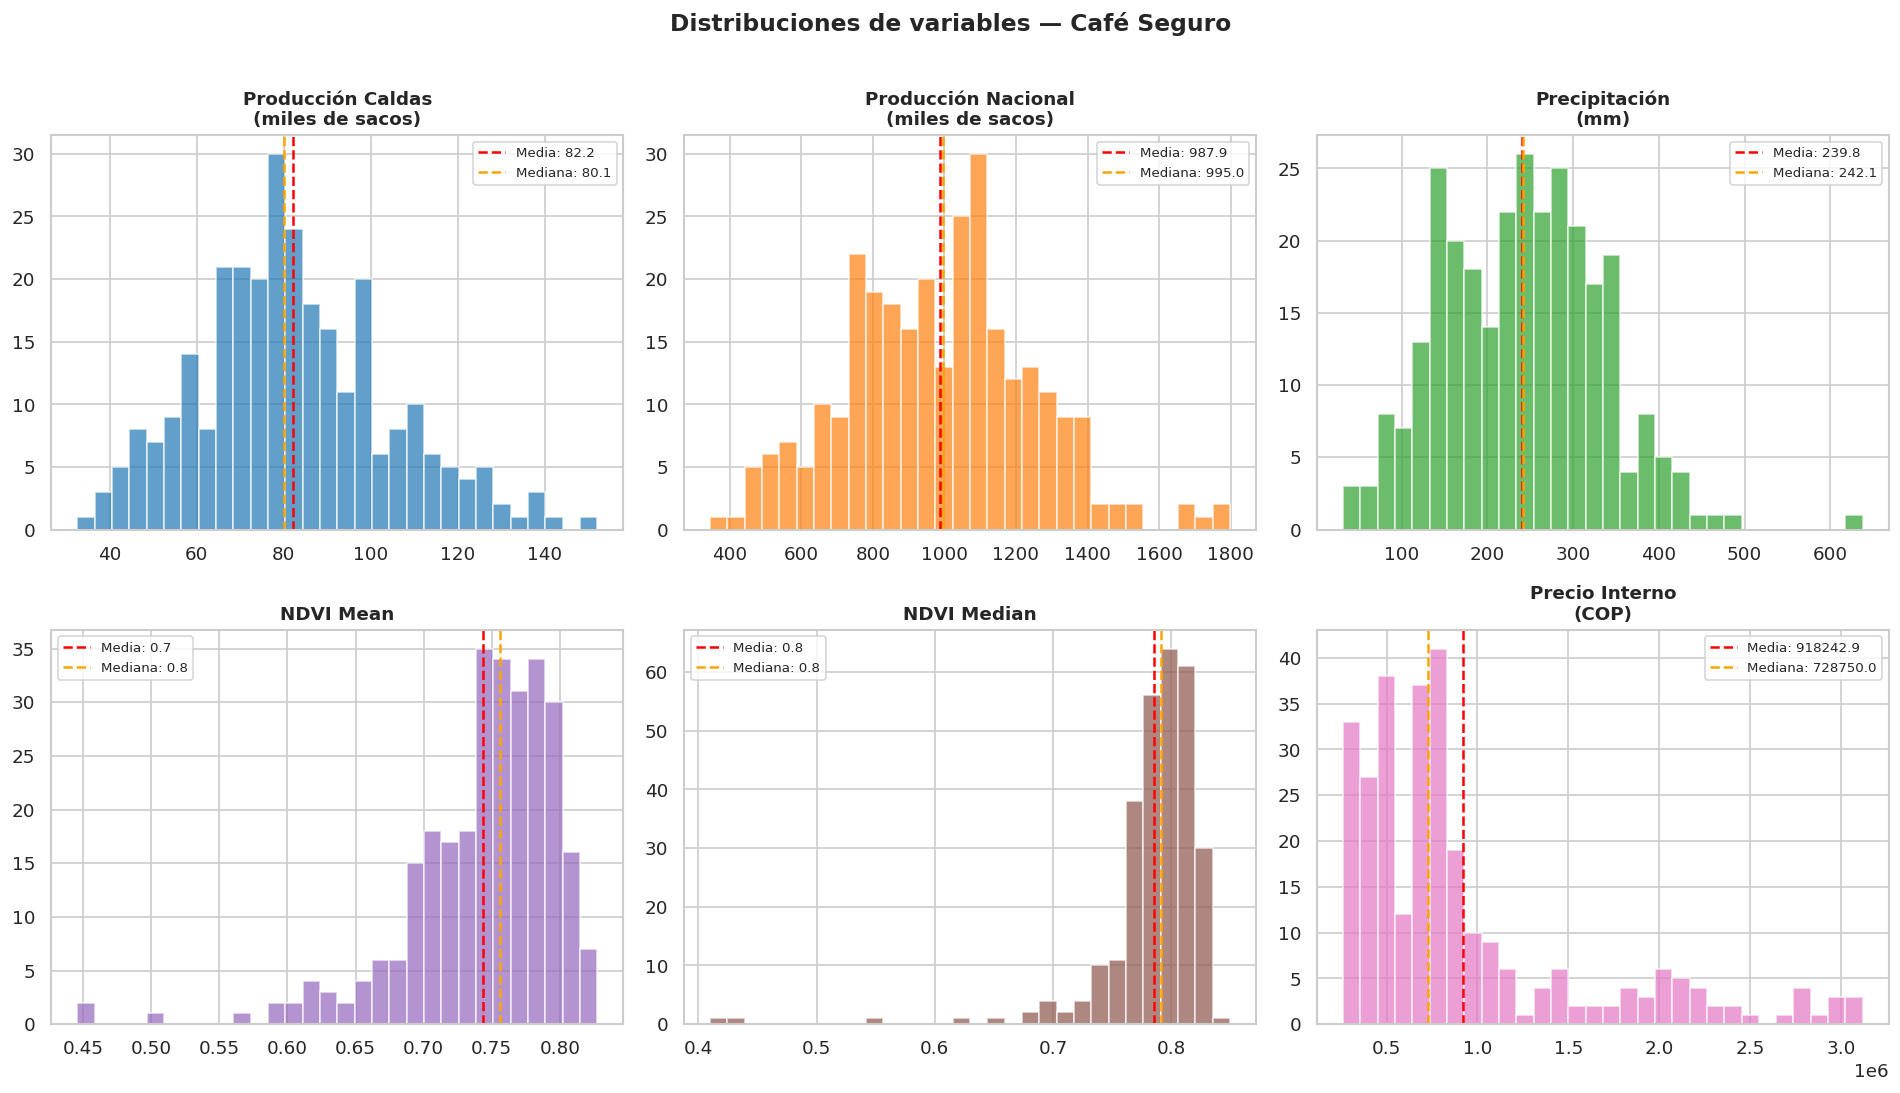

In [39]:
# Histogramas con media y mediana
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

vars_plot = [
    ('prod_caldas_miles_sacos', 'Producción Caldas\n(miles de sacos)', '#1f77b4'),
    ('prod_nacional_miles_sacos', 'Producción Nacional\n(miles de sacos)', '#ff7f0e'),
    ('precip_mm', 'Precipitación\n(mm)', '#2ca02c'),
    ('ndvi_mean', 'NDVI Mean', '#9467bd'),
    ('ndvi_median', 'NDVI Median', '#8c564b'),
    ('precio_interno_cop', 'Precio Interno\n(COP)', '#e377c2'),
]

for ax, (col, titulo, color) in zip(axes, vars_plot):
    data = df[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {data.median():.1f}')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones de variables — Café Seguro', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuciones.png', bbox_inches='tight')
plt.show()

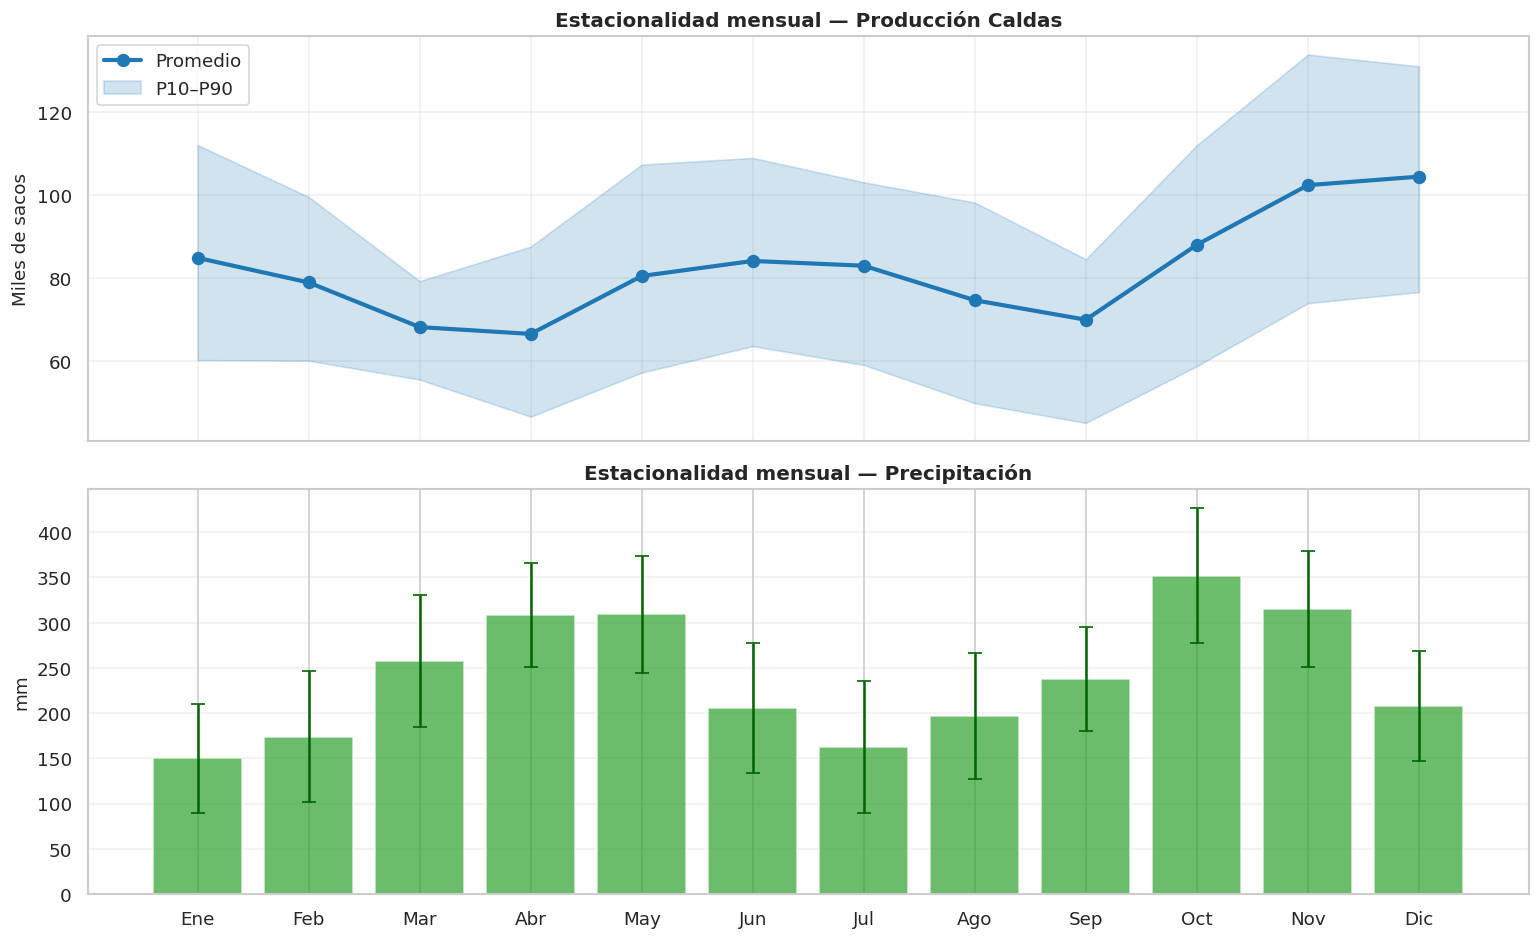

In [40]:
meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

monthly = df.groupby('month').agg(
    prod_media=('prod_caldas_miles_sacos', 'mean'),
    prod_std=('prod_caldas_miles_sacos', 'std'),
    prod_p10=('prod_caldas_miles_sacos', lambda x: x.quantile(0.10)),
    prod_p90=('prod_caldas_miles_sacos', lambda x: x.quantile(0.90)),
    precip_media=('precip_mm', 'mean'),
    precip_std=('precip_mm', 'std'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.plot(monthly['month'], monthly['prod_media'], 'o-', color='#1f77b4',
         linewidth=2.5, markersize=7, label='Promedio')
ax1.fill_between(monthly['month'], monthly['prod_p10'], monthly['prod_p90'],
                 alpha=0.2, color='#1f77b4', label='P10–P90')
ax1.set_ylabel('Miles de sacos', fontsize=11)
ax1.set_title('Estacionalidad mensual — Producción Caldas', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(monthly['month'], monthly['precip_media'], color='#2ca02c', alpha=0.7)
ax2.errorbar(monthly['month'], monthly['precip_media'], yerr=monthly['precip_std'],
             fmt='none', color='darkgreen', capsize=4)
ax2.set_ylabel('mm', fontsize=11)
ax2.set_title('Estacionalidad mensual — Precipitación', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(meses)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('estacionalidad_mensual.png', bbox_inches='tight')
plt.show()

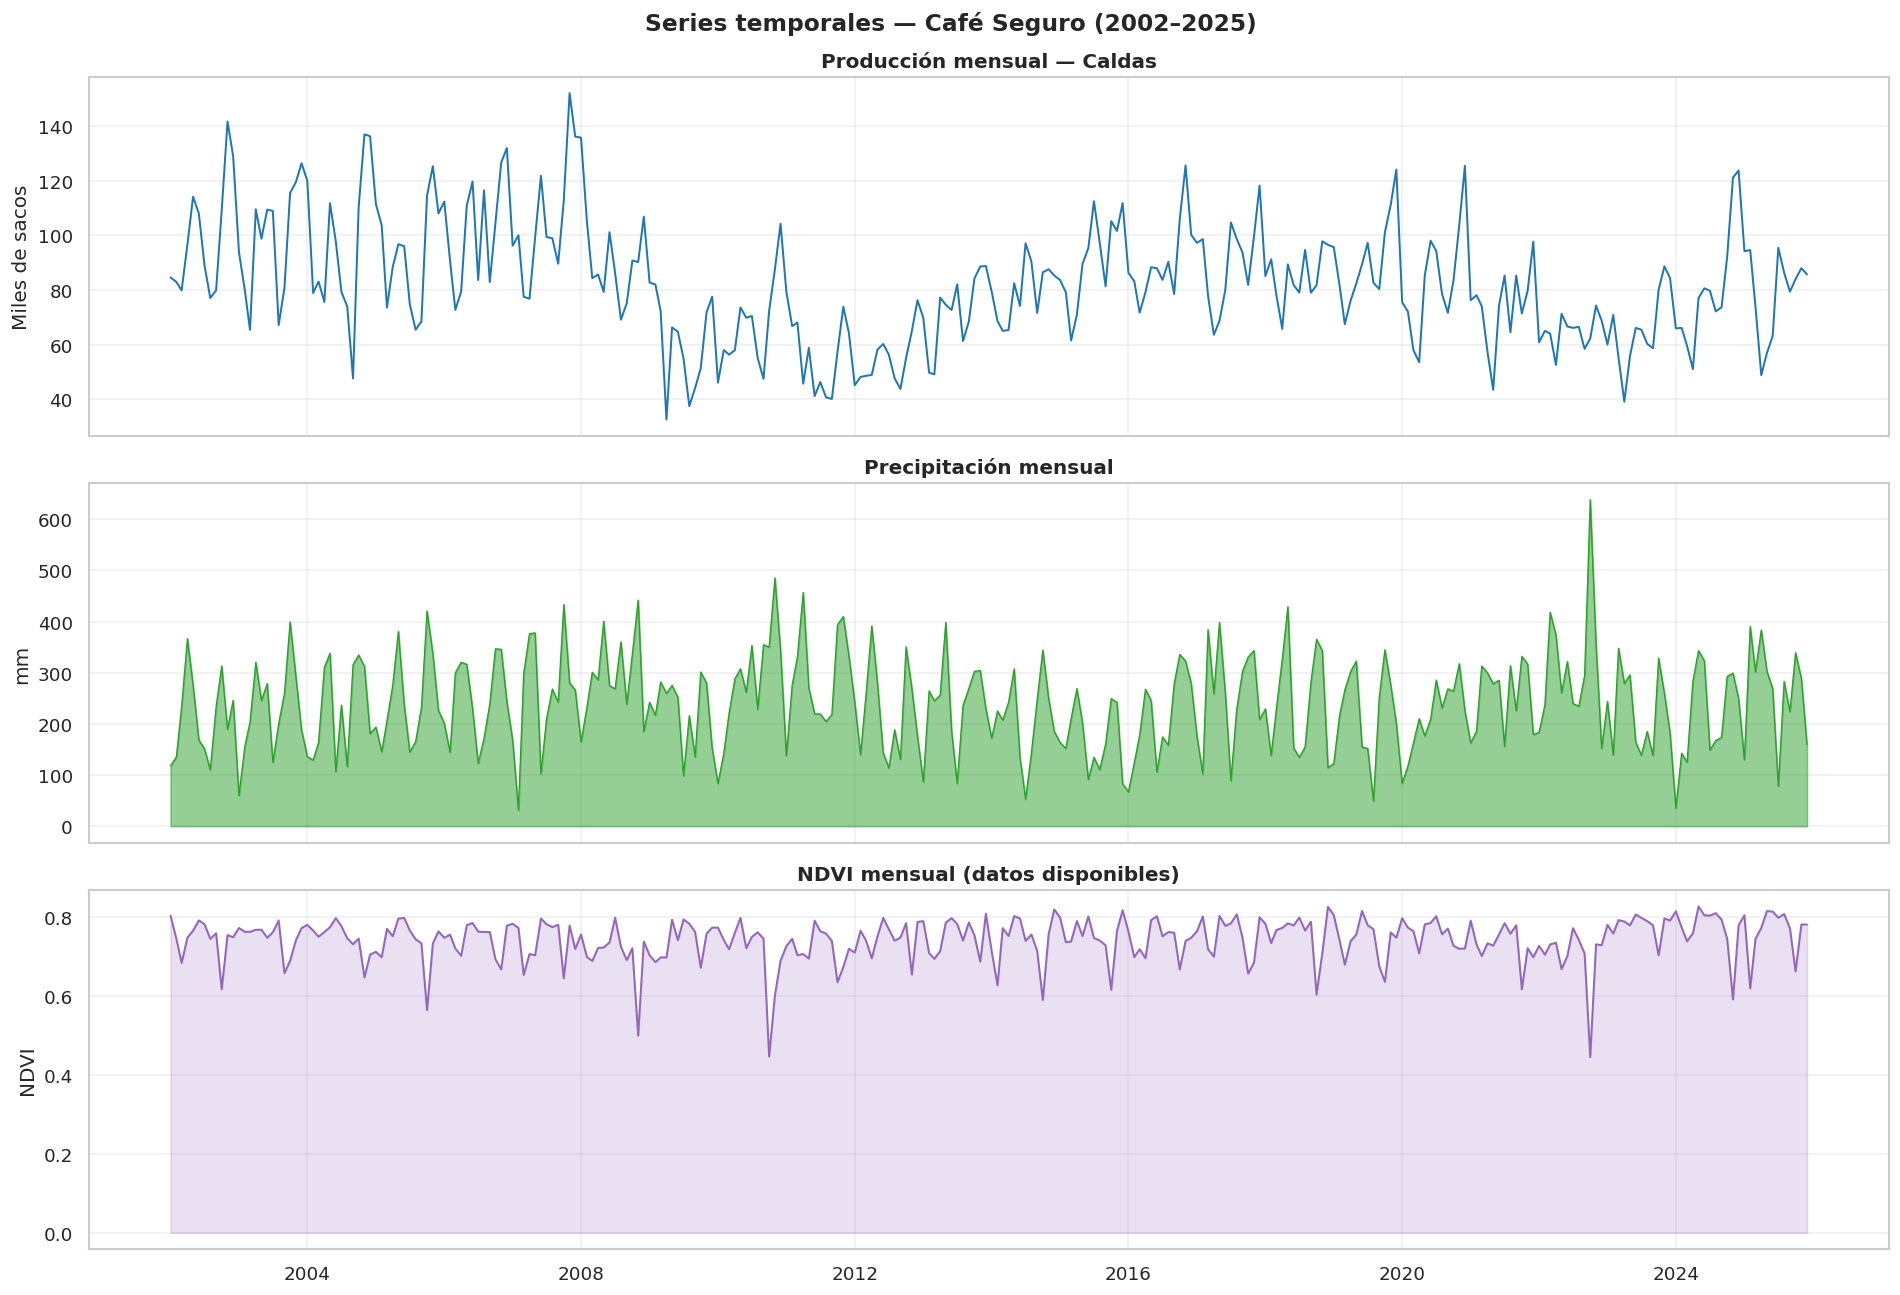

In [41]:
# Series temporales completas (producción + precipitación + NDVI)
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].plot(df['fecha'], df['prod_caldas_miles_sacos'], color='#1f77b4', linewidth=1.2)
axes[0].set_ylabel('Miles de sacos')
axes[0].set_title('Producción mensual — Caldas', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df['fecha'], df['precip_mm'], alpha=0.5, color='#2ca02c')
axes[1].plot(df['fecha'], df['precip_mm'], color='#2ca02c', linewidth=0.8)
axes[1].set_ylabel('mm')
axes[1].set_title('Precipitación mensual', fontweight='bold')
axes[1].grid(True, alpha=0.3)

df_ndvi = df[df['ndvi_mean'].notna()]
axes[2].plot(df_ndvi['fecha'], df_ndvi['ndvi_mean'], color='#9467bd', linewidth=1.2)
axes[2].fill_between(df_ndvi['fecha'], df_ndvi['ndvi_mean'], alpha=0.2, color='#9467bd')
axes[2].set_ylabel('NDVI')
axes[2].set_title('NDVI mensual (datos disponibles)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Series temporales — Café Seguro (2002–2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('series_temporales.png', bbox_inches='tight')
plt.show()

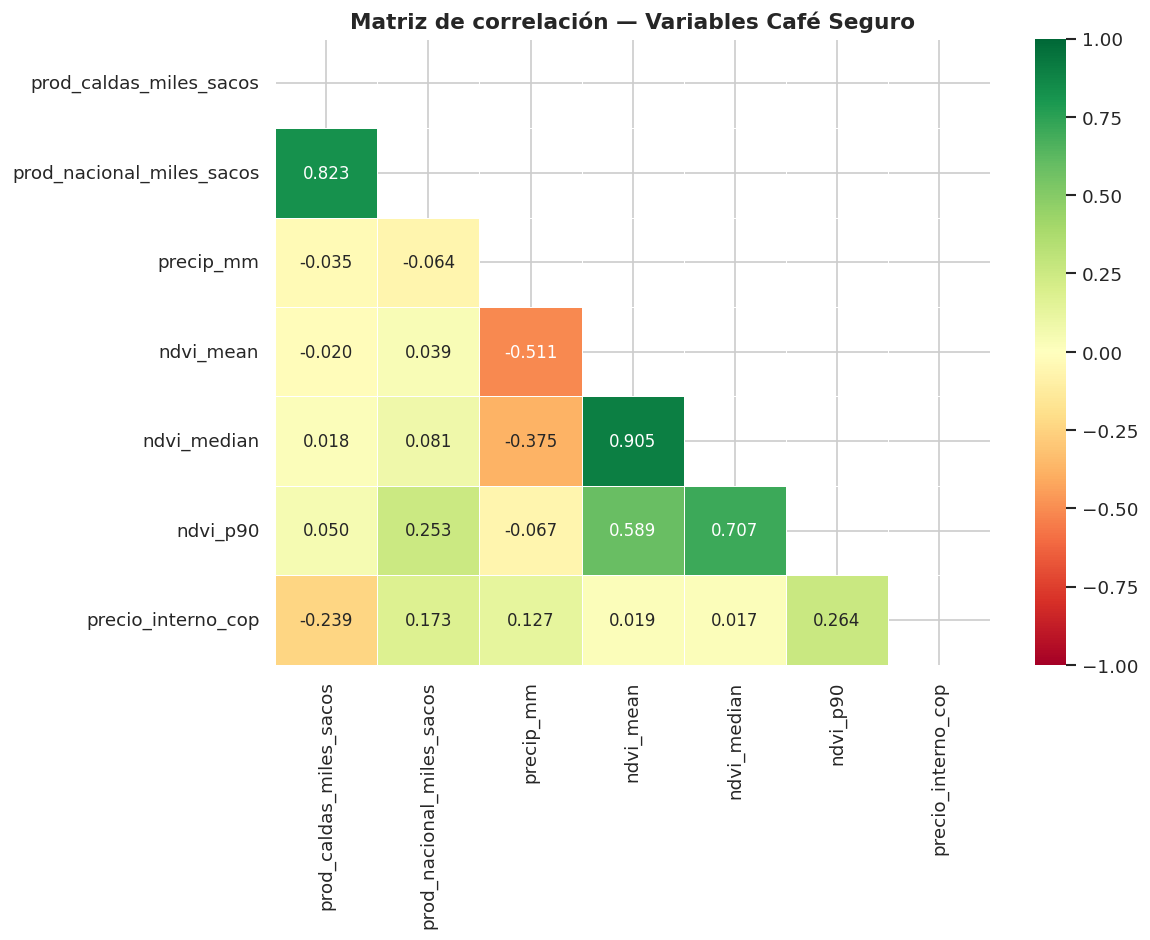

In [42]:
# Matriz de correlación completa
vars_corr = ['prod_caldas_miles_sacos', 'prod_nacional_miles_sacos',
             'precip_mm', 'ndvi_mean', 'ndvi_median', 'ndvi_p90', 'precio_interno_cop']

corr_matrix = df[vars_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={'size': 10})
ax.set_title('Matriz de correlación — Variables Café Seguro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_correlacion.png', bbox_inches='tight')
plt.show()

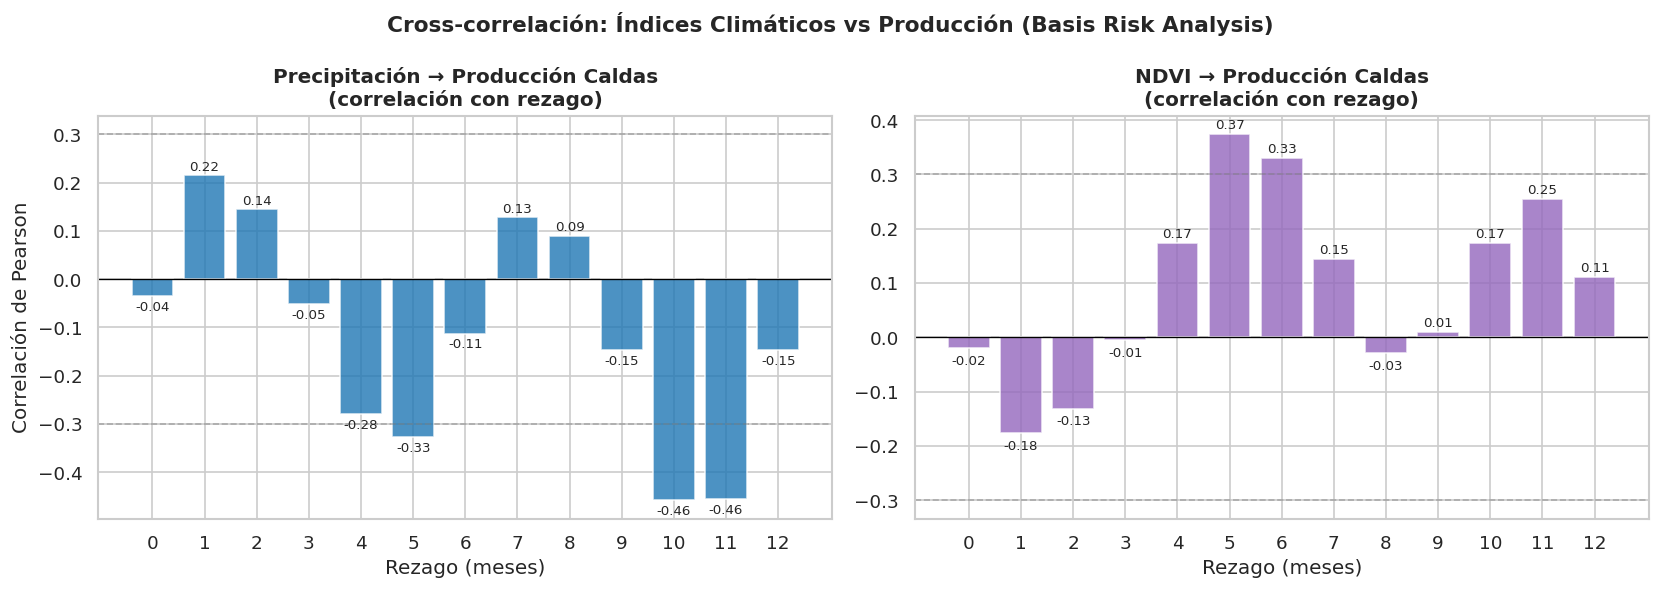


 Lag óptimo precipitación: 10 meses (r = -0.458)
 Lag óptimo NDVI:          5 meses (r = 0.374)


In [43]:
# Correlación con rezagos de 0 a 12 meses
max_lag = 12
lags = range(0, max_lag + 1)
corr_lags_precip = []
corr_lags_ndvi   = []

prod   = df['prod_caldas_miles_sacos'].values
precip = df['precip_mm'].values

for lag in lags:
    if lag == 0:
        r_p, _ = stats.pearsonr(prod, precip)
    else:
        r_p, _ = stats.pearsonr(prod[lag:], precip[:-lag])
    corr_lags_precip.append(r_p)

df_ndvi    = df[df['ndvi_mean'].notna()].copy()
prod_ndvi  = df_ndvi['prod_caldas_miles_sacos'].values
ndvi       = df_ndvi['ndvi_mean'].values

for lag in lags:
    if lag == 0:
        r_n, _ = stats.pearsonr(prod_ndvi, ndvi)
        corr_lags_ndvi.append(r_n)
    else:
        if len(prod_ndvi) > lag:
            r_n, _ = stats.pearsonr(prod_ndvi[lag:], ndvi[:-lag])
            corr_lags_ndvi.append(r_n)
        else:
            corr_lags_ndvi.append(np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(lags, corr_lags_precip, color='#1f77b4', alpha=0.8, edgecolor='white')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axhline(0.3,  color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.axhline(-0.3, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Rezago (meses)')
ax1.set_ylabel('Correlación de Pearson')
ax1.set_title('Precipitación → Producción Caldas\n(correlación con rezago)', fontweight='bold')
ax1.set_xticks(list(lags))
for i, v in enumerate(corr_lags_precip):
    ax1.text(i, v + 0.01 if v >= 0 else v - 0.03, f'{v:.2f}', ha='center', fontsize=8)

ax2.bar(lags, corr_lags_ndvi, color='#9467bd', alpha=0.8, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(0.3,  color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.axhline(-0.3, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Rezago (meses)')
ax2.set_title('NDVI → Producción Caldas\n(correlación con rezago)', fontweight='bold')
ax2.set_xticks(list(lags))
for i, v in enumerate(corr_lags_ndvi):
    if not np.isnan(v):
        ax2.text(i, v + 0.01 if v >= 0 else v - 0.03, f'{v:.2f}', ha='center', fontsize=8)

plt.suptitle('Cross-correlación: Índices Climáticos vs Producción (Basis Risk Analysis)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacion_lags.png', bbox_inches='tight')
plt.show()

lag_opt_precip = np.argmax([abs(c) for c in corr_lags_precip])
lag_opt_ndvi   = np.argmax([abs(c) for c in corr_lags_ndvi if not np.isnan(c)])
print(f'\n Lag óptimo precipitación: {lag_opt_precip} meses (r = {corr_lags_precip[lag_opt_precip]:.3f})')
print(f' Lag óptimo NDVI:          {lag_opt_ndvi} meses (r = {corr_lags_ndvi[lag_opt_ndvi]:.3f})')

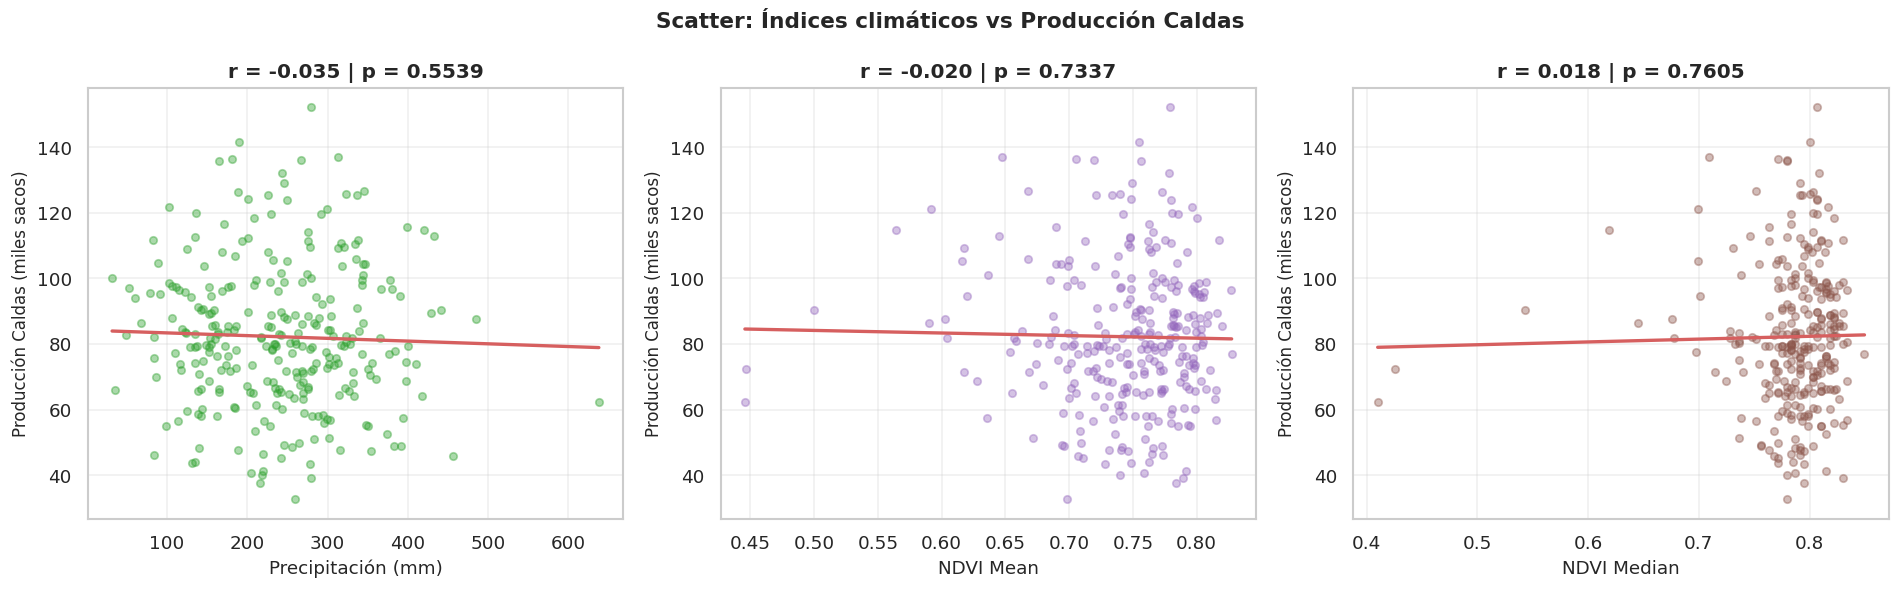

In [44]:
# Scatter plots con regresión lineal
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pares = [
    ('precip_mm',    'prod_caldas_miles_sacos', 'Precipitación (mm)', '#2ca02c'),
    ('ndvi_mean',    'prod_caldas_miles_sacos', 'NDVI Mean',          '#9467bd'),
    ('ndvi_median',  'prod_caldas_miles_sacos', 'NDVI Median',        '#8c564b'),
]

for ax, (x_col, y_col, xlabel, color) in zip(axes, pares):
    data_plot = df[[x_col, y_col]].dropna()
    ax.scatter(data_plot[x_col], data_plot[y_col], alpha=0.4, color=color, s=20)

    slope, intercept, r, p, se = stats.linregress(data_plot[x_col], data_plot[y_col])
    x_line = np.linspace(data_plot[x_col].min(), data_plot[x_col].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2)

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Producción Caldas (miles sacos)', fontsize=10)
    ax.set_title(f'r = {r:.3f} | p = {p:.4f}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter: Índices climáticos vs Producción Caldas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_indices_produccion.png', bbox_inches='tight')
plt.show()

In [45]:
p10 = df['prod_caldas_miles_sacos'].quantile(0.10)
p15 = df['prod_caldas_miles_sacos'].quantile(0.15)
p20 = df['prod_caldas_miles_sacos'].quantile(0.20)
p25 = df['prod_caldas_miles_sacos'].quantile(0.25)
media = df['prod_caldas_miles_sacos'].mean()
std   = df['prod_caldas_miles_sacos'].std()

print('Umbrales candidatos para activación del seguro:')
print(f'  P10:        {p10:.1f} miles de sacos')
print(f'  P15:        {p15:.1f} miles de sacos')
print(f'  P20:        {p20:.1f} miles de sacos')
print(f'  P25:        {p25:.1f} miles de sacos')
print(f'  Media - 1σ: {media - std:.1f} miles de sacos')
print(f'  Media -1.5σ:{media - 1.5*std:.1f} miles de sacos')

UMBRAL = p20  # <── cambiar para análisis de sensibilidad
df['evento_bajo'] = df['prod_caldas_miles_sacos'] < UMBRAL

print(f'\nEventos de producción < P20 ({UMBRAL:.1f} miles sacos):')
print(f'  Total meses: {df["evento_bajo"].sum()} de {len(df)} ({df["evento_bajo"].mean()*100:.1f}%)')

Umbrales candidatos para activación del seguro:
  P10:        55.2 miles de sacos
  P15:        59.6 miles de sacos
  P20:        65.0 miles de sacos
  P25:        66.8 miles de sacos
  Media - 1σ: 60.3 miles de sacos
  Media -1.5σ:49.3 miles de sacos

Eventos de producción < P20 (65.0 miles sacos):
  Total meses: 58 de 288 (20.1%)


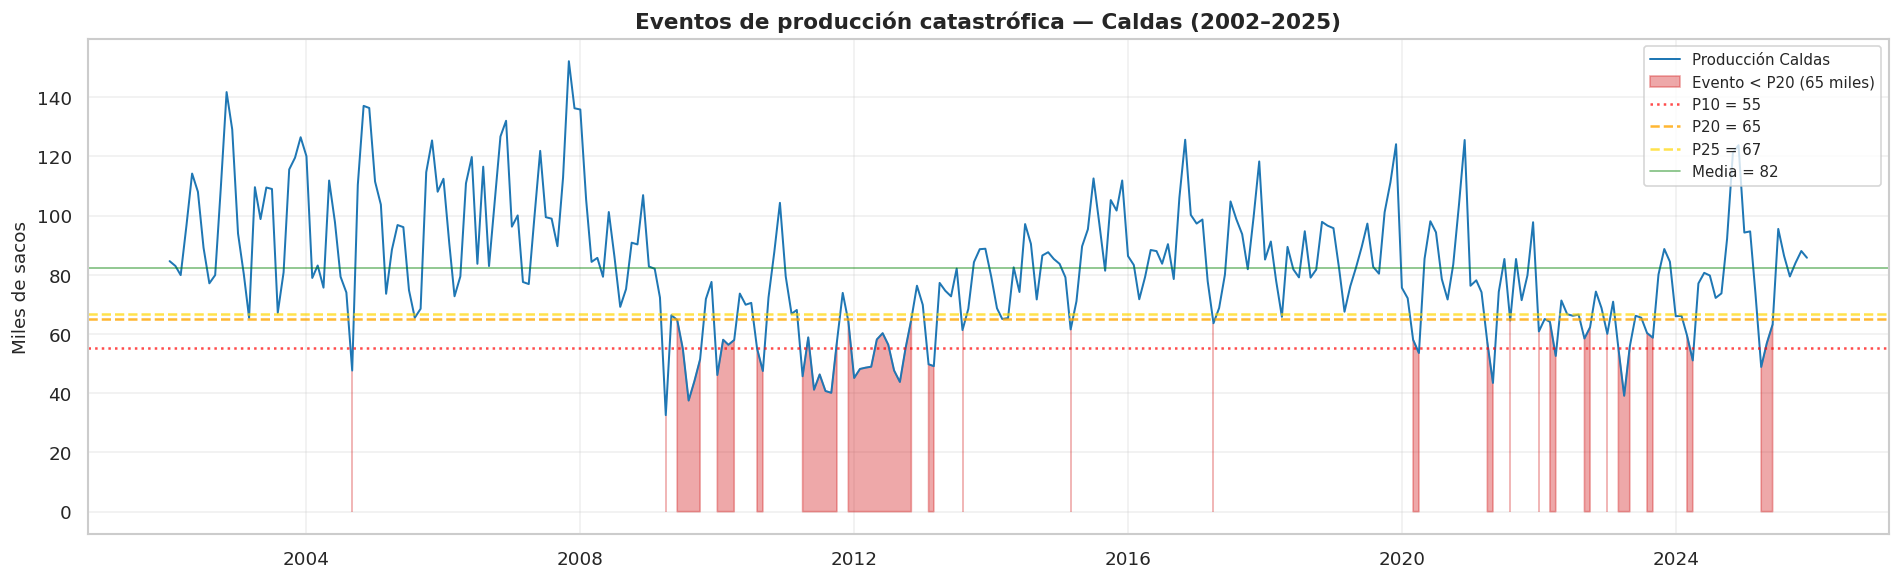

In [46]:
# Serie con eventos marcados y líneas de umbral
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['fecha'], df['prod_caldas_miles_sacos'], color='#1f77b4', linewidth=1.2, label='Producción Caldas')
ax.fill_between(df['fecha'], 0, df['prod_caldas_miles_sacos'],
                where=df['evento_bajo'],
                color='#d62728', alpha=0.4, label=f'Evento < P20 ({UMBRAL:.0f} miles)')

ax.axhline(p10,   color='red',    linestyle=':',  linewidth=1.5, alpha=0.7, label=f'P10 = {p10:.0f}')
ax.axhline(p20,   color='orange', linestyle='--', linewidth=1.5, alpha=0.8, label=f'P20 = {p20:.0f}')
ax.axhline(p25,   color='gold',   linestyle='--', linewidth=1.5, alpha=0.7, label=f'P25 = {p25:.0f}')
ax.axhline(media, color='green',  linestyle='-',  linewidth=1,   alpha=0.5, label=f'Media = {media:.0f}')

ax.set_ylabel('Miles de sacos', fontsize=11)
ax.set_title('Eventos de producción catastrófica — Caldas (2002–2025)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('eventos_catastroficos.png', bbox_inches='tight')
plt.show()

In [47]:
# Análisis de sensibilidad de umbrales
umbrales = {
    'P10':       p10,
    'P15':       p15,
    'P20':       p20,
    'P25':       p25,
    'Media-1σ':  media - std,
    'Media-1.5σ': media - 1.5 * std,
}

rows = []
for nombre, umbral in umbrales.items():
    eventos_u      = df['prod_caldas_miles_sacos'] < umbral
    precip_evento  = df.loc[eventos_u,  'precip_mm'].mean()
    precip_normal  = df.loc[~eventos_u, 'precip_mm'].mean()
    rows.append({
        'Umbral':               nombre,
        'Valor (miles sacos)':  round(umbral, 1),
        'N eventos':            eventos_u.sum(),
        '% meses':              round(eventos_u.mean() * 100, 1),
        'Precip. en evento':    round(precip_evento, 1),
        'Precip. normal':       round(precip_normal, 1),
        'Diferencia precip.':   round(precip_evento - precip_normal, 1),
    })

tabla_umbrales = pd.DataFrame(rows)
print('Análisis de sensibilidad del umbral de activación:')
print(tabla_umbrales.to_string(index=False))

Análisis de sensibilidad del umbral de activación:
    Umbral  Valor (miles sacos)  N eventos  % meses  Precip. en evento  Precip. normal  Diferencia precip.
       P10                 55.2         29     10.1              252.6           238.4                14.3
       P15                 59.6         44     15.3              250.0           238.0                12.1
       P20                 65.0         58     20.1              257.8           235.3                22.6
       P25                 66.8         72     25.0              248.4           236.9                11.5
  Media-1σ                 60.3         46     16.0              247.6           238.3                 9.2
Media-1.5σ                 49.3         21      7.3              248.4           239.1                 9.3


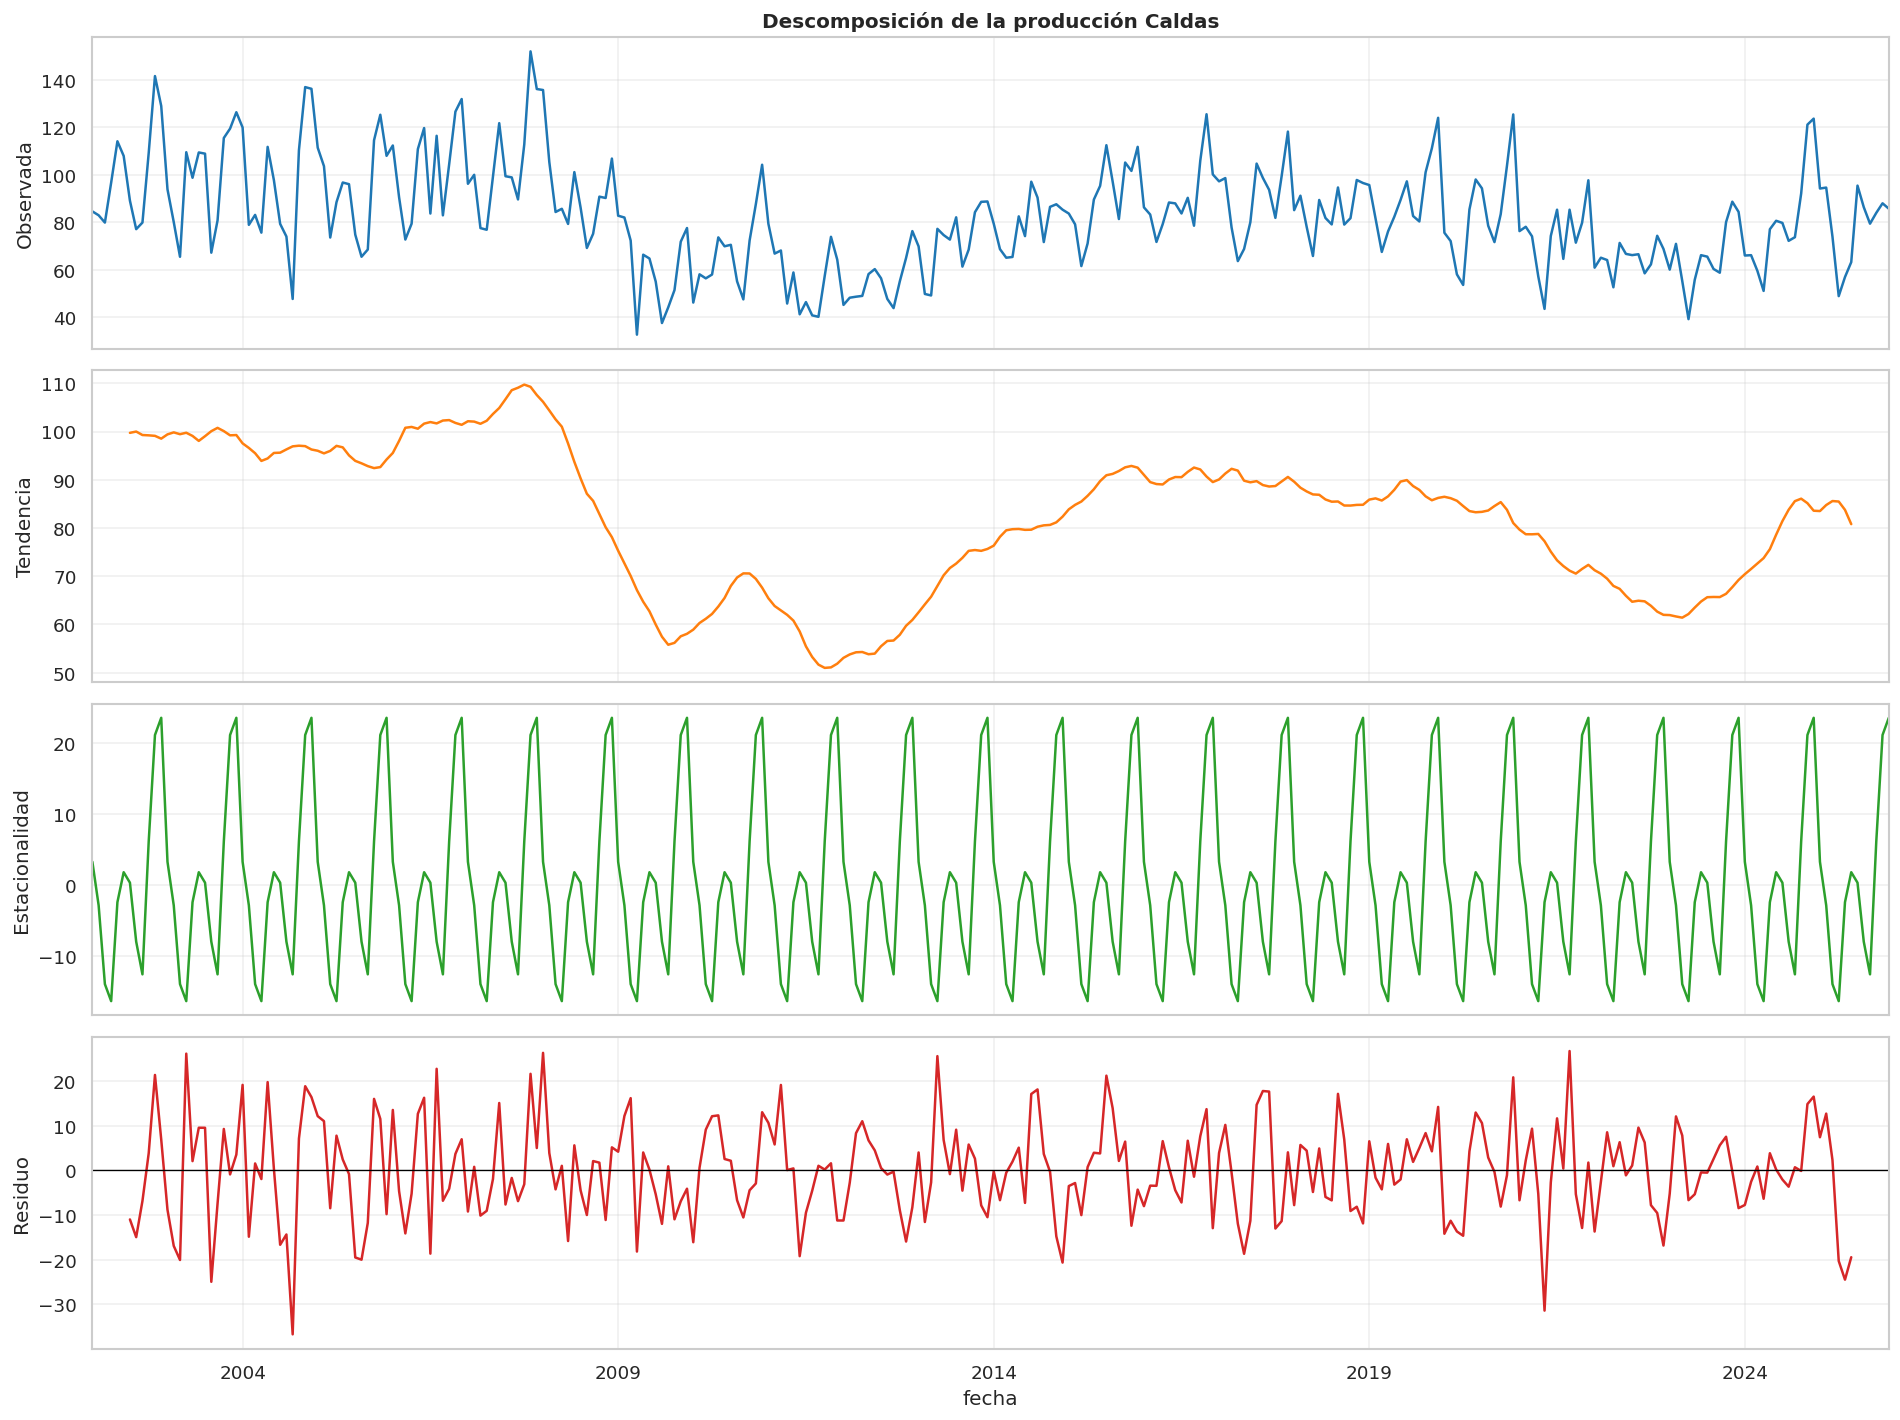

In [48]:
# Descomposición STL (tendencia + estacionalidad + residuo)
ts_prod = df.set_index('fecha')['prod_caldas_miles_sacos']
decomp  = seasonal_decompose(ts_prod, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

decomp.observed.plot(ax=axes[0], color='#1f77b4')
axes[0].set_ylabel('Observada')
axes[0].set_title('Descomposición de la producción Caldas', fontweight='bold')

decomp.trend.plot(ax=axes[1], color='#ff7f0e')
axes[1].set_ylabel('Tendencia')

decomp.seasonal.plot(ax=axes[2], color='#2ca02c')
axes[2].set_ylabel('Estacionalidad')

decomp.resid.plot(ax=axes[3], color='#d62728')
axes[3].set_ylabel('Residuo')
axes[3].axhline(0, color='black', linewidth=0.8)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('descomposicion_stl.png', bbox_inches='tight')
plt.show()

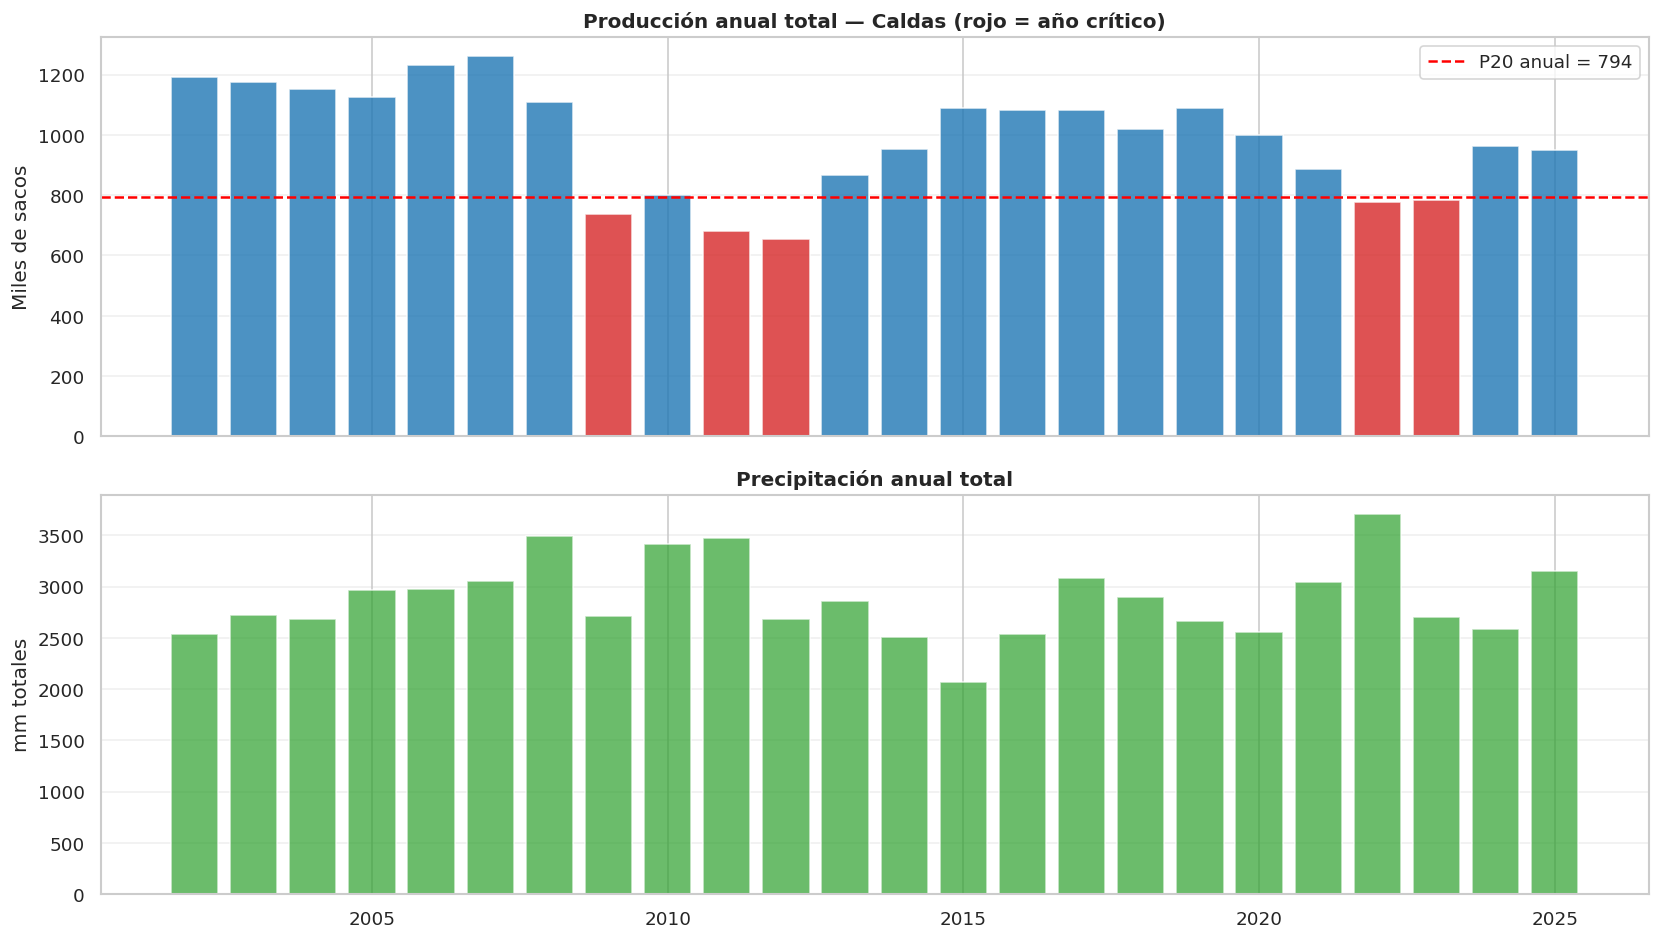

Años críticos identificados:
 year  prod_total  precip_total  n_meses_bajo
 2009  738.170718   2709.824160             6
 2011  682.710977   3469.019120             8
 2012  653.553989   2681.640944            11
 2022  777.039730   3707.129630             5
 2023  784.968175   2702.124970             6


In [49]:
# Producción anual con años críticos en rojo
anual = df.groupby('year').agg(
    prod_total=('prod_caldas_miles_sacos', 'sum'),
    precip_total=('precip_mm', 'sum'),
    precip_media=('precip_mm', 'mean'),
    n_meses_bajo=('evento_bajo', 'sum'),
).reset_index()

p20_anual = anual['prod_total'].quantile(0.20)
anual['año_critico'] = anual['prod_total'] < p20_anual

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

colors = ['#d62728' if c else '#1f77b4' for c in anual['año_critico']]
ax1.bar(anual['year'], anual['prod_total'], color=colors, alpha=0.8, edgecolor='white')
ax1.axhline(p20_anual, color='red', linestyle='--', linewidth=1.5, label=f'P20 anual = {p20_anual:.0f}')
ax1.set_ylabel('Miles de sacos')
ax1.set_title('Producción anual total — Caldas (rojo = año crítico)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(anual['year'], anual['precip_total'], color='#2ca02c', alpha=0.7, edgecolor='white')
ax2.set_ylabel('mm totales')
ax2.set_title('Precipitación anual total', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('produccion_anual.png', bbox_inches='tight')
plt.show()

print('Años críticos identificados:')
print(anual[anual['año_critico']][['year','prod_total','precip_total','n_meses_bajo']].to_string(index=False))